## Code for armB during (July 21st 2025)

In [1]:
import numpy as np
import pandas as pd
import scipy.integrate
import math
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from matplotlib import animation, rc
from IPython.display import HTML
import time
import multiprocessing as mp
import os

from scipy.stats import zscore

from sklearn.manifold import TSNE
from sklearn.mixture import BayesianGaussianMixture

import phenograph as pg
import random

In [2]:

import marsilea as ma
import marsilea.plotter as mp

In [3]:
colours_30 = ["firebrick","gold","royalblue","green","dimgray","orchid","darkviolet",
              "red", "orange", "limegreen", "blue", "purple", "seagreen","gold","darkolivegreen",
              "lightpink","thistle","mistyrose","saddlebrown","slategrey","powderblue",
            "palevioletred","mediumvioletred","yellowgreen","lemonchiffon","chocolate",
              "lightsalmon","lightcyan","lightblue", "darkorange","magenta","sienna","midnightblue","fuchsia","violet","tomato","aqua",
             "darkslategray","coral","lightcoral","sandybrown","indianred","olivedrab","darkgreen","blueviolet","forestgreen","darkred",
             "dimgray","teal","cadetblue"]

In [4]:
## read in data

arm = 'ArmB_2024/'
log_data = 'CN_during/' 

data_path = arm+log_data

count_matrix =  np.array(pd.read_csv(os.path.join(data_path+'count_data_combined.csv'), header=None,index_col=None)) 

In [5]:
cluster_asgn =  np.array(pd.read_csv(os.path.join(data_path+'cluster_asgnments_kmeans_nolog.csv'), header=None,index_col=None)) 
X_2d_1 =  np.array(pd.read_csv(os.path.join(data_path+'X_2d_tsne_nolog.csv'), header=None,index_col=None)) 


In [6]:
print(count_matrix.shape)
print(cluster_asgn.shape)
print(X_2d_1.shape)


(328763, 31)
(328763, 1)
(328763, 2)


In [7]:
unique, counts = np.unique(cluster_asgn, return_counts=True)
print('unique',str(unique))
print(counts)

unique [ 1  4  8  9 11 12 13 14 15 16 17 19 20 22 23 24]
[ 55444      4      2      5 121208 151310      3      1    643     16
     97      5      9      4      9      3]


In [8]:
cluster_asgn1 = cluster_asgn.flatten()

#### scanpy

In [34]:
import scipy 
import os
import scipy.io as sio
import scanpy as sc

In [35]:
df = count_matrix[:,21:26]
adata = sc.AnnData(df)


adata.obs_names = [f"Cell_{i:d}" for i in range(adata.n_obs)]
adata.var_names = [f"Gene_{i:d}" for i in range(adata.n_vars)]

adata.obs["louvain"] = cluster_asgn1
print(adata.var_names[:10])

Index(['Gene_0', 'Gene_1', 'Gene_2', 'Gene_3', 'Gene_4'], dtype='object')


In [36]:
adata

AnnData object with n_obs × n_vars = 328763 × 5
    obs: 'louvain'

In [37]:
y_marker = ['FoxP3','CD3',  'CD8', 'PD1','PDL1' ]
cell_markers = {
    "T reg cells": ["FoXP3"],
    "CD3+ T cells": ["CD3"],
    "CD8 T cells": ["CD8"],
    "PD-1 cells": ["PD-1"],
    "PD-L1 cells": ["PD-L1"],
}

cells, markers = [], []
for c, ms in cell_markers.items():
    cells += [c] * len(ms)
    markers += ms

uni_cells = list(cell_markers.keys())
cell_colors = [
    "#568564",
    "#DC6B19",
    "#F72464",
    "#005585",
    "#9876DE",
    "#405559",
    "#58DADA",
    "#F85959",
]
cmapper = dict(zip(uni_cells, cell_colors))

In [38]:
exp = adata[:, 0:5].X.toarray()

#m = ma.Heatmap(exp, cmap="viridis", height=3.5, width=3)
#m.render()

In [39]:
agg = sc.get.aggregate(adata[:, 0:5], by="louvain", func=["mean", "count_nonzero"])
agg.obs["cell_counts"] = adata.obs["louvain"].value_counts()
agg

AnnData object with n_obs × n_vars = 16 × 5
    obs: 'louvain', 'cell_counts'
    layers: 'mean', 'count_nonzero'

In [40]:
agg_exp = agg.layers["mean"]
agg_count = agg.layers["count_nonzero"]
agg_cell_counts = adata.obs["louvain"].value_counts().to_numpy()

In [41]:
agg_cell_counts

array([151310, 121208,  55444,    643,     97,     16,      9,      9,
            5,      5,      4,      4,      3,      3,      2,      1])

In [42]:
adata.obs["louvain"].value_counts()

louvain
12    151310
11    121208
1      55444
15       643
17        97
16        16
23         9
20         9
19         5
9          5
22         4
4          4
13         3
24         3
8          2
14         1
Name: count, dtype: int64

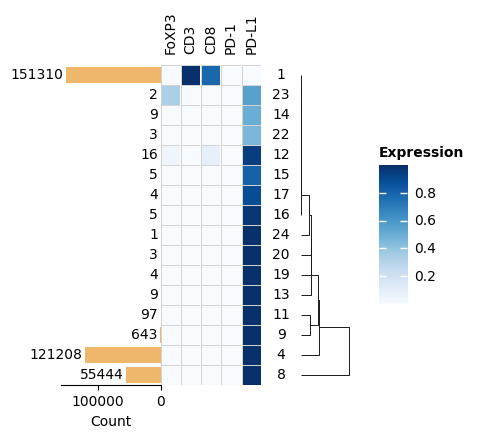

In [43]:
h, w = agg_exp.shape

m = ma.Heatmap(
    agg_exp,
    height=h / 5,
    width=w / 5,
    cmap="Blues",
    linewidth=0.5,
    linecolor="lightgray",
    label="Expression",
)

m.add_right(mp.Labels(agg.obs["louvain"], align="center"), pad=0.1)
m.add_top(mp.Labels(markers), pad=0.1)

m.group_cols(cells, order=uni_cells)
'''
m.add_top(mp.Chunk(uni_cells, fill_colors=cell_colors, rotation=90))
'''
m.add_left(mp.Numbers(agg_cell_counts, color="#EEB76B", label="Count"))
m.add_dendrogram("right", pad=0.1)
m.add_legends()

m.render()

In [44]:
uni_cells

['T reg cells', 'CD3+ T cells', 'CD8 T cells', 'PD-1 cells', 'PD-L1 cells']

### merge clusters

In [21]:
cluster_asgn2 = np.zeros(cluster_asgn1.shape)

In [22]:
## pd-l1 high
row = np.where(cluster_asgn1==16)
cluster_asgn2[row]=np.int64(100)
row = np.where(cluster_asgn1==24)
cluster_asgn2[row]=np.int64(100)
row = np.where(cluster_asgn1==20)
cluster_asgn2[row]=np.int64(100)
row = np.where(cluster_asgn1==19)
cluster_asgn2[row]=np.int64(100)
row = np.where(cluster_asgn1==13)
cluster_asgn2[row]=np.int64(100)
row = np.where(cluster_asgn1==11)
cluster_asgn2[row]=np.int64(100)
row = np.where(cluster_asgn1==9)
cluster_asgn2[row]=np.int64(100)
row = np.where(cluster_asgn1==4)
cluster_asgn2[row]=np.int64(100)
row = np.where(cluster_asgn1==8)
cluster_asgn2[row]=np.int64(100)

#pdl1 medium
row = np.where(cluster_asgn1==15)
cluster_asgn2[row]=np.int64(100)
row = np.where(cluster_asgn1==17)
cluster_asgn2[row]=np.int64(100)

#pdl1 low
row = np.where(cluster_asgn1==14)
cluster_asgn2[row]=np.int64(100)
row = np.where(cluster_asgn1==22)
cluster_asgn2[row]=np.int64(100)


#cd3/8
row = np.where(cluster_asgn1==1)
cluster_asgn2[row]=np.int64(200)

#fox pdl1
row = np.where(cluster_asgn1==23)
cluster_asgn2[row]=np.int64(300)

#fox cd8 pdl1
row = np.where(cluster_asgn1==12)
cluster_asgn2[row]=np.int64(300)
cluster_asgn2 = cluster_asgn2 -1

In [23]:
cluster_asgn2 = np.int64(cluster_asgn2/100)

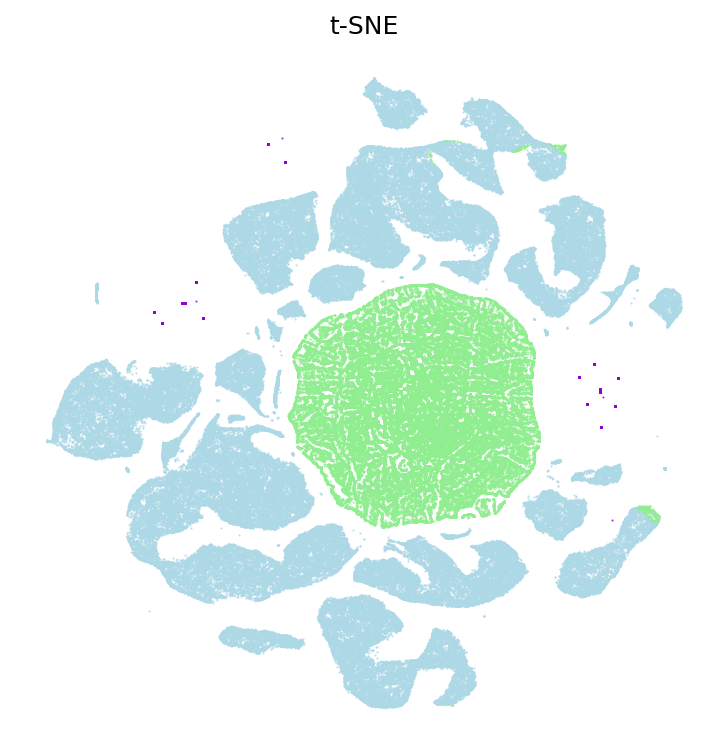

In [29]:
#t-SNE plots
unique1, count1 = np.unique(cluster_asgn2, return_counts=True)
target_ids = range(len(unique1))
plt.figure(figsize=(6,6),dpi=150)
plt.axis('off')
colors = ['lightgreen','darkviolet','lightblue']
for i,  label in zip(target_ids,  unique1):
    #print(label)
    c=colours_30[i+3] #cm.colors[i]
    plt.scatter(X_2d_1[ cluster_asgn2==(i), 0], X_2d_1[ cluster_asgn2==(i), 1], color=colors[i],label=label,s=1,linewidths=0,alpha=0.8)
#plt.legend(loc=3)
plt.title('t-SNE')
plt.show()


In [31]:
unique1, count1 = np.unique(cluster_asgn2, return_counts=True)
target_ids = range(len(unique1))
cell_classes = ['PD-L1+','CD3+ CD8+','FoxP3+ CD8+ PD-L1+']
#louvain_names = np.zeros(np.shape(cluster_asgn2))
listOfStrings = [" "] * 328763
col_len = []
for i,  label in zip(target_ids,  unique1):
    print(label)
    s= np.array(np.where(cluster_asgn2==label)).flatten()
    print(s.shape)
    print(s)
    col_len.append(np.int64(s.shape))
    #print(s)
    
    for j in range(len(s)):
        listOfStrings[s[j]]=cell_classes[label]
    

0
(122000,)
[     1      2      3 ... 328660 328667 328758]
1
(55444,)
[151551 196566 206582 ... 318783 318784 318785]
2
(151319,)
[     0     31     50 ... 328760 328761 328762]


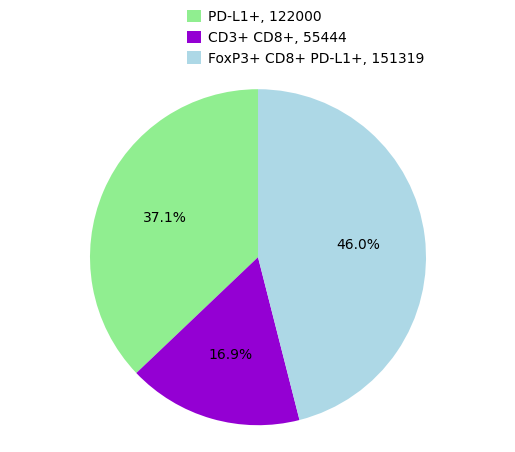

In [32]:
import matplotlib.pyplot as plt
labels = cell_classes#['dogs','cats','birds','fish']
sizes = np.array(col_len).flatten() #[34, 24,18,13]
c= ["green","dimgray","orchid","darkviolet",
              "red", "orange"]
pie = plt.pie(sizes,autopct='%1.1f%%', startangle=90, colors=colors)
plt.axis('equal')
plt.legend( loc = 'right', labels=labels)

labels = [f'{l}, {s:0.0f}' for l, s in zip(labels, sizes)]
plt.legend(bbox_to_anchor=(0.85, 1), loc=4, labels=labels)


plt.show()